In [ ]:
import sys
from pathlib import Path
import pandas as pd
import csv
import numpy as np
import re
import matplotlib.pyplot as plt
from adjustText import adjust_text

from nhlpy import NHLClient
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

In [ ]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = Path("data/raw")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Import alias lookup and comment scraping functions
from src.scrape_all_comments import get_all_comments
from src.sharks_aliases import sharks_aliases, build_alias_lookup, find_players_in_comment
from src.redact_names import redact_comment

In [2]:
client = NHLClient()

In [3]:
roster = client.teams.team_roster(team_abbr="SJS", season="20252026")
roster

{'forwards': [{'id': 8484801,
   'headshot': 'https://assets.nhle.com/mugs/nhl/20252026/SJS/8484801.png',
   'firstName': {'default': 'Macklin'},
   'lastName': {'default': 'Celebrini'},
   'sweaterNumber': 71,
   'positionCode': 'C',
   'shootsCatches': 'L',
   'heightInInches': 72,
   'weightInPounds': 190,
   'heightInCentimeters': 183,
   'weightInKilograms': 86,
   'birthDate': '2006-06-13',
   'birthCity': {'default': 'North Vancouver'},
   'birthCountry': 'CAN',
   'birthStateProvince': {'default': 'BC'}},
  {'id': 8480848,
   'headshot': 'https://assets.nhle.com/mugs/nhl/20252026/SJS/8480848.png',
   'firstName': {'default': 'Ty'},
   'lastName': {'default': 'Dellandrea'},
   'sweaterNumber': 10,
   'positionCode': 'C',
   'shootsCatches': 'R',
   'heightInInches': 74,
   'weightInPounds': 185,
   'heightInCentimeters': 188,
   'weightInKilograms': 84,
   'birthDate': '2000-07-21',
   'birthCity': {'default': 'Port Perry'},
   'birthCountry': 'CAN',
   'birthStateProvince': {'d

In [4]:
# Get a game's complete data
game_id = "2025021220"
boxscore = client.game_center.boxscore(game_id)
play_by_play = client.game_center.play_by_play(game_id)

# Analyze the game
away_team = boxscore['awayTeam']['abbrev']
home_team = boxscore['homeTeam']['abbrev']
away_score = boxscore['awayTeam']['score']
home_score = boxscore['homeTeam']['score']

print(f"Final: {away_team} {away_score} - {home_team} {home_score}")

# Count shots by period
shots_by_period = {}
for play in play_by_play.get('plays', []):
    if play['typeDescKey'] == 'shot-on-goal':
        period = play['periodDescriptor'].get('number', 'Unknown')
        if period not in shots_by_period:
            shots_by_period[period] = 0
        shots_by_period[period] += 1

for period, shots in shots_by_period.items():
    print(f"Period {period}: {shots} shots")

Final: NSH 6 - SJS 3
Period 1: 14 shots
Period 2: 20 shots
Period 3: 18 shots


In [5]:
boxscore['awayTeam']

{'id': 18,
 'commonName': {'default': 'Predators'},
 'abbrev': 'NSH',
 'score': 6,
 'sog': 34,
 'logo': 'https://assets.nhle.com/logos/nhl/svg/NSH_light.svg',
 'darkLogo': 'https://assets.nhle.com/logos/nhl/svg/NSH_dark.svg',
 'placeName': {'default': 'Nashville'},
 'placeNameWithPreposition': {'default': 'Nashville', 'fr': 'de Nashville'}}

In [6]:
stats = boxscore.get('playerByGameStats')

def get_active_roster(team_side):
    team_stats = stats.get(team_side)
    roster = set()
    
    for category in ['forwards', 'defense', 'goalies']:
        for player in team_stats.get(category):
            roster.add(player.get('name').get('default'))
    return roster

away_roster = get_active_roster('awayTeam')
home_roster = get_active_roster('homeTeam')

print(f"{home_team} Active Players")
print(home_roster)

SJS Active Players
{'N. Leddy', 'T. Toffoli', 'S. Dickinson', 'M. Ferraro', 'W. Smith', 'K. Sherwood', 'I. Chernyshov', 'C. Graf', 'S. Mukhamadullin', 'A. Wennberg', 'B. Goodrow', 'Y. Askarov', 'W. Eklund', 'M. Misa', 'M. Celebrini', 'A. Nedeljkovic', 'V. Desharnais', 'A. Gaudette', 'D. Orlov', 'Z. Ostapchuk'}


In [7]:
start_time = boxscore.get('startTimeUTC')
start_time

'2026-04-05T02:00:00Z'

### Scrape Reddit post

In [ ]:
# Scrape comments from a game thread
url = "https://www.reddit.com/r/SanJoseSharks/comments/1sc9qab/game_thread_nashville_predators_35319_san_jose/"
comments = get_all_comments(url)
comments.sort(key=lambda x: x["time_utc"])

# Save comments to CSV
file_name = RAW_DATA_DIR / f"{game_id}_comments.csv"

with open(file_name, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["comment", "time_utc"])
    writer.writeheader()
    writer.writerows(comments)

print(f"Saved {len(comments)} comments to {file_name}")

Saved 2074 comments to 2025021220_comments.csv


### Process Comments

In [192]:
# Import finetuned RoBERTa model
MODEL_PATH = "./models/roberta-sharks-finetuned"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

sentiment_model = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    truncation=True,
    max_length=128
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5087.90it/s]


In [193]:
WORD_PATTERN = re.compile(r"[a-zA-Z0-9']+")
REPEATED_CHAR_PATTERN = re.compile(r'(.)\1{2,}')


def process_comments(df, alias_to_player, long_aliases, sentiment_model):
    df["players_mentioned"] = df["comment"].apply(lambda x: find_players_in_comment(x, alias_to_player, long_aliases))
    df = df[df["players_mentioned"].apply(bool)].copy()

    labels = []
    confidences = []
    for _, row in df.iterrows():
        comment = row["comment"]
        words = WORD_PATTERN.findall(str(comment))
        positive = False

        # Edge case where a comments is only a player's name in all caps
        if len(words) <= 2 and words[0].isupper() and words[0].lower() in alias_to_player:
            positive = True

        for word in words:
            word = word.lower()
            if word.endswith("'s"):
                word = word[:-2]
            # Edge case where the last letter of a player's name is repeated
            if REPEATED_CHAR_PATTERN.search(word):
                normalized = REPEATED_CHAR_PATTERN.sub(r'\1\1', word)
                if normalized in alias_to_player or normalized[:-1] in alias_to_player:
                    positive = True
                    break

        if positive:
            labels.append("positive")
            confidences.append(None)
        else:
            redacted = redact_comment(comment, alias_to_player, long_aliases)
            result = sentiment_model(redacted)[0]
            labels.append(result["label"])
            confidences.append(result["score"])

    df["label"] = labels
    df["confidence"] = confidences
    return df

In [194]:
file_name = RAW_DATA_DIR / f"{game_id}_comments.csv"
if not file_name.exists():
    raise FileNotFoundError(f"Could not find {file_name}")

df = pd.read_csv(file_name)

# Filter for comments after game start time
puck_drop = (pd.to_datetime(boxscore.get('startTimeUTC')) + pd.Timedelta(minutes=5)).strftime('%Y-%m-%dT%H:%M:%SZ')
df = df[df["time_utc"] >= puck_drop]

alias_to_player, long_aliases = build_alias_lookup(sharks_aliases)

# Find player mentions in comments
df["players_mentioned"] = df["comment"].apply(lambda x: find_players_in_comment(x, alias_to_player, long_aliases))
df = df[df["players_mentioned"].apply(bool)]

df = process_comments(df, alias_to_player, long_aliases, sentiment_model)

df.head(20)

,comment,time_utc,players_mentioned,label,confidence
131,wills suit today was rad af,2026-04-05T02:05:40Z,{'W. Smith': {'will'}},positive,0.985257
138,If you win today I think they make it and lose...,2026-04-05T02:06:21Z,{'W. Smith': {'will'}},neutral,0.720151
139,Kiefer goal anyone?,2026-04-05T02:06:55Z,{'K. Sherwood': {'kiefer'}},neutral,0.748829
147,haha i love sherwood,2026-04-05T02:10:00Z,{'K. Sherwood': {'sherwood'}},positive,0.983911
148,i love sherwood,2026-04-05T02:10:02Z,{'K. Sherwood': {'sherwood'}},positive,0.987255
149,kiefer 🩵😩,2026-04-05T02:10:06Z,{'K. Sherwood': {'kiefer'}},negative,0.453525
152,I need Sherwood mic'ed up. For my mental health,2026-04-05T02:10:42Z,{'K. Sherwood': {'sherwood'}},neutral,0.661261
156,"Mic'd up Sherwood would be wild, but it would ...",2026-04-05T02:11:40Z,{'K. Sherwood': {'sherwood'}},neutral,0.577335
157,yeah mack and cherny with immediately dzone tu...,2026-04-05T02:11:52Z,"{'M. Celebrini': {'mack'}, 'I. Chernyshov': {'...",negative,0.539641
160,They already testing Asky bruh,2026-04-05T02:12:06Z,{'Y. Askarov': {'asky'}},neutral,0.691020


### Finetuned RoBERTa Model Testing

In [179]:
find_players_in_comment("willmack", alias_to_player, long_aliases)

{}

In [184]:
sentiment_model("kiefer!")

[{'label': 'positive', 'score': 0.5940611362457275}]

In [62]:
sentiment_model("klingberg 😡")

[{'label': 'negative', 'score': 0.8836201429367065}]

### Aggregate Sentiment Analysis by Player

In [92]:
def build_player_comments(df):
    rows = []

    for _, row in df.iterrows():
        players = row["players_mentioned"]
        for player in players.keys():
            rows.append({
                "player": player,
                "comment": row["comment"],
                "label": row["label"],
                "confidence": row["confidence"]
            })

    return pd.DataFrame(rows)

In [93]:
player_df = build_player_comments(df)
player_df.head()

,player,comment,label,confidence
0,W. Smith,wills suit today was rad af,positive,0.985534
1,W. Smith,If you win today I think they make it and lose...,neutral,0.742666
2,K. Sherwood,Kiefer goal anyone?,neutral,0.772639
3,K. Sherwood,haha i love sherwood,positive,0.985347
4,K. Sherwood,i love sherwood,positive,0.987929


In [100]:
label_counts = player_df.groupby(["player", "label"]).size().unstack(fill_value=0)
label_counts

label,negative,neutral,positive
player,,,
A. Gaudette,3,1,1
A. Nedeljkovic,6,5,2
A. Wennberg,12,16,70
B. Goodrow,0,3,0
C. Graf,3,7,10
D. Orlov,19,4,2
I. Chernyshov,3,4,4
J. Klingberg,0,3,0
K. Sherwood,3,14,23


In [123]:
def aggregate_sentiment(player_df):
    label_counts = player_df.groupby(["player", "label"]).size().unstack(fill_value=0)
    label_counts = label_counts[["positive", "neutral", "negative"]]

    label_counts["mentions"] = label_counts[["positive", "neutral", "negative"]].sum(axis=1)
    label_counts["positive_pct"] = label_counts["positive"] / label_counts["mentions"]
    label_counts["neutral_pct"] = label_counts["neutral"] / label_counts["mentions"]
    label_counts["negative_pct"] = label_counts["negative"] / label_counts["mentions"]
    label_counts["sentiment_score"] = (label_counts["positive"] - label_counts["negative"]) / label_counts["mentions"]

    result = label_counts.reset_index()
    result.columns.name = None
    return result.sort_values(by="mentions", ascending=False)


sentiment_df = aggregate_sentiment(player_df)
sentiment_df

,player,positive,neutral,negative,mentions,positive_pct,neutral_pct,negative_pct,sentiment_score
21,W. Smith,28,38,92,158,0.177215,0.240506,0.582278,-0.405063
22,Y. Askarov,42,49,51,142,0.295775,0.345070,0.359155,-0.063380
12,N. Leddy,70,27,6,103,0.679612,0.262136,0.058252,0.621359
2,A. Wennberg,70,16,12,98,0.714286,0.163265,0.122449,0.591837
9,M. Celebrini,38,26,19,83,0.457831,0.313253,0.228916,0.228916
20,W. Eklund,26,19,29,74,0.351351,0.256757,0.391892,-0.040541
8,K. Sherwood,23,14,3,40,0.575000,0.350000,0.075000,0.500000
5,D. Orlov,2,4,19,25,0.080000,0.160000,0.760000,-0.680000
4,C. Graf,10,7,3,20,0.500000,0.350000,0.150000,0.350000
16,S. Mukhamadullin,3,4,10,17,0.176471,0.235294,0.588235,-0.411765


In [128]:
def skater_stats_to_df(stats):
    rows = []

    for group in ["forwards", "defense"]:
        for player in stats[group]:
            rows.append({
                "player": player["name"]["default"],
                "plus_minus": player["plusMinus"],
                "goals": player["goals"],
                "assists": player["assists"],
                "points": player["points"],
                "shots": player["sog"],
                "toi": player["toi"],
            })

    return pd.DataFrame(rows)

skater_stats = skater_stats_to_df(stats["homeTeam"])
skater_stats.head()

,player,plus_minus,goals,assists,points,shots,toi
0,W. Smith,-2,0,0,0,3,18:52
1,A. Wennberg,-1,1,0,1,2,20:31
2,B. Goodrow,0,0,0,0,0,10:49
3,K. Sherwood,0,0,0,0,1,13:00
4,C. Graf,1,0,1,1,3,17:03


In [130]:
merged = sentiment_df.merge(skater_stats, on="player")

merged.head()

,player,positive,neutral,negative,mentions,positive_pct,neutral_pct,negative_pct,sentiment_score,plus_minus,goals,assists,points,shots,toi
0,W. Smith,28,38,92,158,0.177215,0.240506,0.582278,-0.405063,-2,0,0,0,3,18:52
1,N. Leddy,70,27,6,103,0.679612,0.262136,0.058252,0.621359,2,1,1,2,2,20:42
2,A. Wennberg,70,16,12,98,0.714286,0.163265,0.122449,0.591837,-1,1,0,1,2,20:31
3,M. Celebrini,38,26,19,83,0.457831,0.313253,0.228916,0.228916,-1,1,0,1,5,23:40
4,W. Eklund,26,19,29,74,0.351351,0.256757,0.391892,-0.040541,0,0,1,1,1,14:49


### Analysis Plots

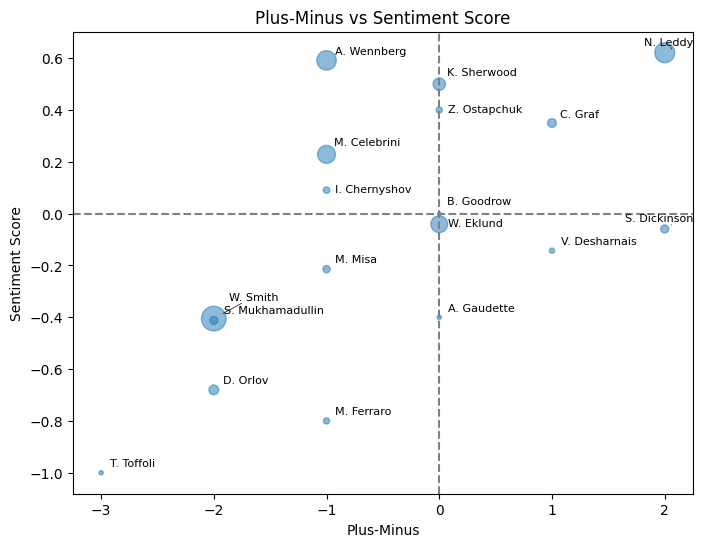

In [ ]:


plt.figure(figsize=(8, 6))
plt.scatter(merged["plus_minus"], merged["sentiment_score"], s=merged["mentions"] * 2, alpha=0.5)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

player_labels = []
for _, row in merged.iterrows():
    player_labels.append(plt.text(row["plus_minus"] + 0.06, row["sentiment_score"] + 0.015, row["player"], fontsize=8))

adjust_text(player_labels, arrowprops=dict(arrowstyle="-", linewidth=0.5))

plt.xlabel("Plus-Minus")
plt.ylabel("Sentiment Score")
plt.title("Plus-Minus vs Sentiment Score")

plt.show()

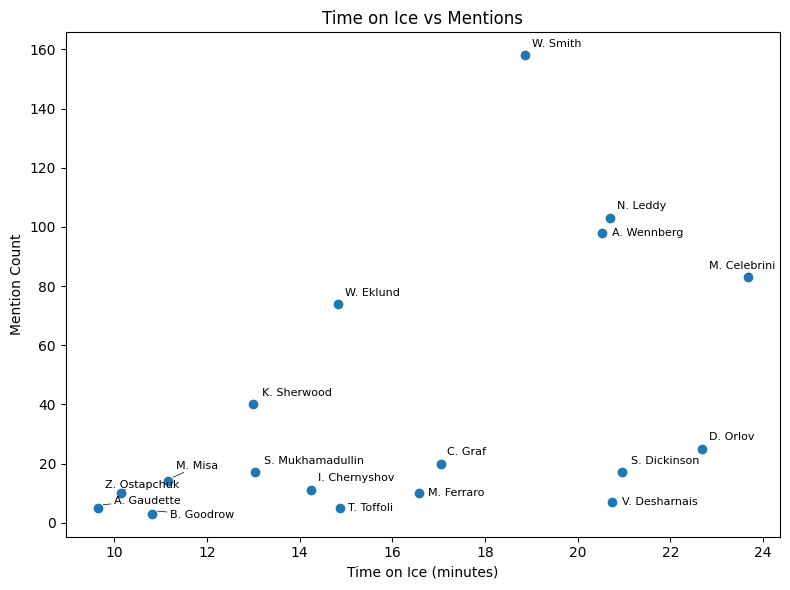

In [169]:
def toi_to_minutes(toi):
    minutes, seconds = toi.split(":")
    return int(minutes) + int(seconds) / 60

merged["toi_minutes"] = merged["toi"].apply(toi_to_minutes)

plt.figure(figsize=(8, 6))

plt.scatter(merged["toi_minutes"], merged["mentions"])

player_labels = []

for _, row in merged.iterrows():
    label = plt.text(row["toi_minutes"] + 0.05, row["mentions"] + 1, row["player"], fontsize=8)
    player_labels.append(label)

adjust_text(
    player_labels,
    x=merged["toi_minutes"],
    y=merged["mentions"],
    arrowprops=dict(arrowstyle="-", linewidth=0.5)
)

plt.xlabel("Time on Ice (minutes)")
plt.ylabel("Mention Count")
plt.title("Time on Ice vs Mentions")

plt.tight_layout()
plt.show()

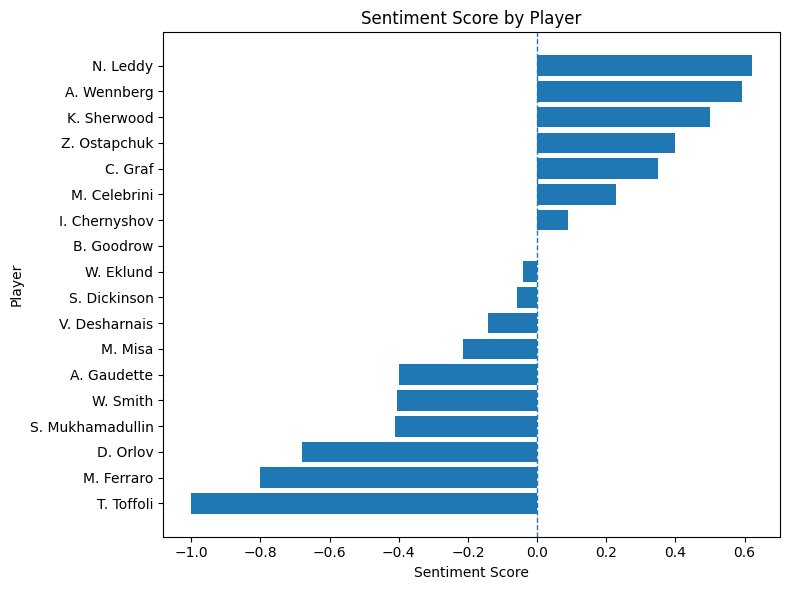

In [178]:
plot_df = merged.sort_values("sentiment_score")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["player"], plot_df["sentiment_score"])
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Sentiment Score")
plt.ylabel("Player")
plt.title("Sentiment Score by Player")
plt.tight_layout()
plt.show()

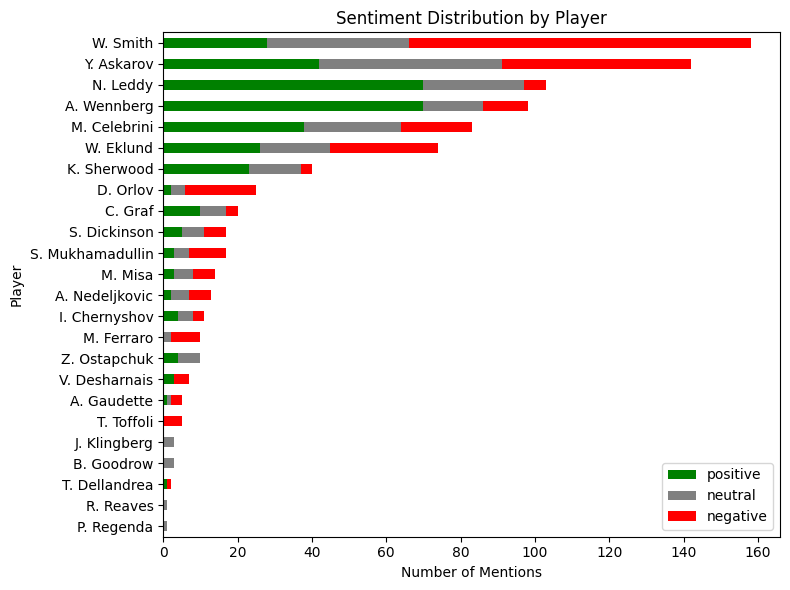

In [177]:
plot_df = sentiment_df.sort_values("mentions")

plot_df.set_index("player")[["positive", "neutral", "negative"]].plot(
    kind="barh",
    stacked=True,
    figsize=(8, 6),
    color=["green", "gray", "red"]
)

plt.xlabel("Number of Mentions")
plt.ylabel("Player")
plt.title("Sentiment Distribution by Player")
plt.tight_layout()
plt.show()